In [69]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import m2cgen as m2c
import itertools
import re
import matplotlib.pyplot as plt

df_train = pd.read_csv("data/1.csv", encoding="1251", sep=";")
df_train.columns = df_train.columns.str.strip()

df_test = pd.read_csv("data/example.csv", encoding="utf-8")
df_test.columns = df_test.columns.str.strip()
labels_true = df_test.pop("0 - Bad, 1 - Good")

# ==========================================
# 1. ОТНОСИТЕЛЬНЫЕ ПРИЗНАКИ (Исправленные)
# ==========================================
def extract_features(signal, window_size=15):
    """
    Вычисляет ОТНОСИТЕЛЬНЫЕ признаки.
    Смотрит на diff (разницу с предыдущей точкой) - это лучший маркер для скачков.
    """
    diff = signal.diff().abs().fillna(0)
    rolling_median = signal.rolling(window=window_size, min_periods=1).median().fillna(0)
    rolling_std = signal.rolling(window=window_size, min_periods=1).std().fillna(0)
    
    # Стабилизатор 0.1 - сглаживает микро-дребезг и защищает от деления на ноль
    base_level = np.abs(rolling_median) + 0.1 
    
    rel_diff = diff / base_level
    rel_std = rolling_std / base_level
    
    features = pd.DataFrame({
        'rel_diff': rel_diff,
        'rel_std': rel_std
    })
    
    return features.bfill()

In [61]:
def compute_metrics(labels_true, labels_pred, dp=4) -> dict:
    metrics = dict()
    metrics["accuracy"] = round(accuracy_score(labels_true, labels_pred), dp)
    metrics["precision"] = round(precision_score(labels_true, labels_pred, pos_label=0, zero_division=0), dp)
    metrics["recall"] = round(recall_score(labels_true, labels_pred, pos_label=0, zero_division=0), dp)
    metrics["f1"] = round(f1_score(labels_true, labels_pred, pos_label=0, zero_division=0), dp)

    return metrics

In [62]:
def _train_model(df_train, window_size, percentile_diff, threshold, max_depth, time_column='TimeStamp',) -> DecisionTreeClassifier:
    all_real_features = []
    for col in[c for c in df_train.columns if c != time_column]:
        feats = extract_features(df_train[col], window_size)
        all_real_features.append(feats.values)
    X_real = np.vstack(all_real_features)
    
    p_diff = np.percentile(X_real[:, 0], percentile_diff)
    p_std = np.percentile(X_real[:, 1], percentile_diff)
    
    threshold_diff = max(p_diff * 5, threshold)
    threshold_std = max(p_std * 5, threshold)
    
    mask_clean = (X_real[:, 0] < threshold_diff) & (X_real[:, 1] < threshold_std)
    X_normal = X_real[mask_clean]
    y_normal = np.ones(len(X_normal))
    
    n_anomalies = int(len(X_normal) * 0.1)
    
    X_anom_diff = np.column_stack((
        np.random.uniform(threshold_diff * 1.1, threshold_diff * 10, n_anomalies),
        np.random.uniform(0, p_std, n_anomalies)
    ))
    X_anom_std = np.column_stack((
        np.random.uniform(0, p_diff, n_anomalies),
        np.random.uniform(threshold_std * 1.1, threshold_std * 10, n_anomalies)
    ))
    X_anom_both = np.column_stack((
        np.random.uniform(threshold_diff * 1.1, threshold_diff * 10, n_anomalies),
        np.random.uniform(threshold_std * 1.1, threshold_std * 10, n_anomalies)
    ))
    
    X_anomalous = np.vstack((X_anom_diff, X_anom_std, X_anom_both))
    y_anomalous = np.zeros(len(X_anomalous))
    
    X_train = np.vstack((X_normal, X_anomalous))
    y_train = np.concatenate((y_normal, y_anomalous))
    
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(X_train, y_train)

    return model
    

In [ ]:
def tune_hyperparameters(df_train, df_test, labels_true, test_sensor_col, param_grid, target_metric='f1'):
    """
    Перебирает сетку гиперпараметров и находит лучшую модель.
    
    test_sensor_col - название колонки в df_test, для которой у нас есть labels_true 
                      (например, "Тм на входе в Д").
    target_metric - 'f1', 'recall', 'precision' или 'accuracy'.
    """
    # Распаковываем сетку параметров во все возможные комбинации
    keys = param_grid.keys()
    values = (param_grid[key] for key in keys)
    combinations =[dict(zip(keys, combination)) for combination in itertools.product(*values)]
    
    print(f"🚀 Начинаем поиск. Всего комбинаций: {len(combinations)}\n")
    
    best_params = None
    best_score = -1.0
    best_metrics = None
    results_history =[]

    for i, params in enumerate(combinations):
        w_size = params['window_size']
        p_diff = params['percentile_diff']
        thresh = params['threshold']
        m_depth = params['max_depth']
        
        # --- 1. ОБУЧЕНИЕ (в памяти, без сохранения файлов) ---
        model = _train_model(df_train=df_train, window_size=w_size, percentile_diff=p_diff, threshold=thresh, max_depth=m_depth)
        
        # --- 2. ИНФЕРЕНС НА ТЕСТЕ ---
        # ВАЖНО: Тестовые признаки извлекаем с ТЕМ ЖЕ window_size
        test_signal = df_test[test_sensor_col]
        test_features = extract_features(test_signal, w_size)
        X_test = test_features.values
        
        labels_pred = model.predict(X_test).astype(int)
        
        # --- 3. РАСЧЕТ МЕТРИК ---
        metrics = compute_metrics(labels_true, labels_pred)
        current_score = metrics[target_metric]
        
        # Сохраняем в историю
        trial_result = {**params, **metrics}
        results_history.append(trial_result)
        
        if current_score > best_score:
            best_score = current_score
            best_params = params
            best_metrics = metrics
            
        # Раскомментируйте строку ниже, если хотите видеть лог каждого шага
        # print(f"[{i+1}/{len(combinations)}] {target_metric}={current_score:.4f} | {params}")

    print("="*60)
    print(f"🏆 ЛУЧШИЕ ПАРАМЕТРЫ ПО МЕТРИКЕ '{target_metric.upper()}':")
    print(f"Параметры: {best_params}")
    print(f"Метрики:   {best_metrics}")
    print("="*60)
    
    # Возвращаем датафрейм с историей (чтобы можно было отсортировать и посмотреть)
    history_df = pd.DataFrame(results_history).sort_values(by=target_metric, ascending=False)
    return best_params, history_df

In [64]:
# Задаем варианты для каждого параметра
param_grid = {
    'window_size':[5, 10, 15, 20],        # Разные размеры скользящего окна
    'percentile_diff':[65, 75, 85, 95],   # Разная жесткость фильтрации обучающих данных
    'threshold':[0.001, 0.005, 0.01],     # Минимальные пороги (0.1%, 0.5%, 1%)
    'max_depth': [3, 4, 5]                 # Глубина дерева
}

# Запускаем тюнинг. Укажите название вашей колонки, для которой есть labels_true!
best_params, history = tune_hyperparameters(
    df_train=df_train,
    df_test=df_test,
    labels_true=labels_true,
    test_sensor_col="Тм на входе в Д", # <--- Измените на нужное имя
    param_grid=param_grid,
    target_metric='f1' # Можно поставить 'recall', чтобы поймать максимум красных точек
)

🚀 Начинаем поиск. Всего комбинаций: 144

🏆 ЛУЧШИЕ ПАРАМЕТРЫ ПО МЕТРИКЕ 'F1':
Параметры: {'window_size': 10, 'percentile_diff': 65, 'threshold': 0.01, 'max_depth': 3}
Метрики:   {'accuracy': 0.9905, 'precision': 0.9783, 'recall': 1.0, 'f1': 0.989}


In [65]:
def train_universal_model(df, time_column='TimeStamp', window_size=15, 
                          models_dir="saved_models", c_models_dir="c_models", percentile_diff=75, threshold=0.005, max_depth=4):
    
    os.makedirs(models_dir, exist_ok=True)
    os.makedirs(c_models_dir, exist_ok=True)
    
    model = _train_model(df, window_size=window_size, time_column=time_column, percentile_diff=percentile_diff,
                         threshold=threshold, max_depth=max_depth)
    
    joblib.dump(model, os.path.join(models_dir, "UNIVERSAL_model.pkl"))
    
    c_code = m2c.export_to_c(model)
    c_code_with_info = (
        "// UNIVERSAL ML MODEL FOR ALL SENSORS\n"
        "// OUTPUT: 1.0 = Good (Normal), 0.0 = Bad (Noise/Anomaly)\n\n"
    ) + c_code
    
    with open(os.path.join(c_models_dir, "UNIVERSAL_model.c"), "w") as f:
        f.write(c_code_with_info)


train_universal_model(df_train, **best_params)

In [ ]:
def clean_filename(name):
    """Убираем спецсимволы для безопасного сохранения CSV."""
    return re.sub(r'[^a-zA-Zа-яА-Я0-9]', '_', name).strip('_')

def run_universal_inference(inference_df, time_column='TimeStamp', window_size=15, 
                            models_dir="saved_models", reports_dir="inference_reports"):
    
    os.makedirs(reports_dir, exist_ok=True)
    
    model_path = os.path.join(models_dir, "UNIVERSAL_model.pkl")
    if not os.path.exists(model_path):
        print("[INFERENCE] ⚠️ ОШИБКА: Универсальная модель не найдена!")
        return
        
    print("[INFERENCE] Загрузка Универсальной Модели...")
    model = joblib.load(model_path)
    
    # Берем ВСЕ колонки, кроме времени
    sensor_columns = [col for col in inference_df.columns if col != time_column]
    
    for raw_col_name in sensor_columns:
        print(f"[INFERENCE] Анализ потока: '{raw_col_name}'...")
        
        signal = inference_df[raw_col_name]
        features = extract_features(signal, window_size)
        X = features.values
        
        # Предсказание Дерева: сразу 0 или 1
        preds = model.predict(X)
        
        # Формируем отчет точно по ТЗ (сохраняя оригинальное имя датчика в шапке)
        out_df = pd.DataFrame({
            time_column: inference_df[time_column],
            raw_col_name: signal, 
            '0 - Bad, 1 - Good': preds.astype(int)
        })
        
        # Сохраняем в CSV
        safe_name = clean_filename(raw_col_name)
        report_path = os.path.join(reports_dir, f"{safe_name}_report.csv")
        out_df.to_csv(report_path, index=False, encoding='utf-8-sig')

        return out_df
        
    print(f"\n✅ Инференс завершен. Создано {len(sensor_columns)} отчетов в '{reports_dir}'.")

# Запуск

result = run_universal_inference(df_test)
labels_pred = result["0 - Bad, 1 - Good"]

[INFERENCE] Загрузка Универсальной Модели...
[INFERENCE] Анализ потока: 'Тм на входе в Д'...


Загрузка файла: inference_reports/Тм_на_входе_в_Д_report.csv...


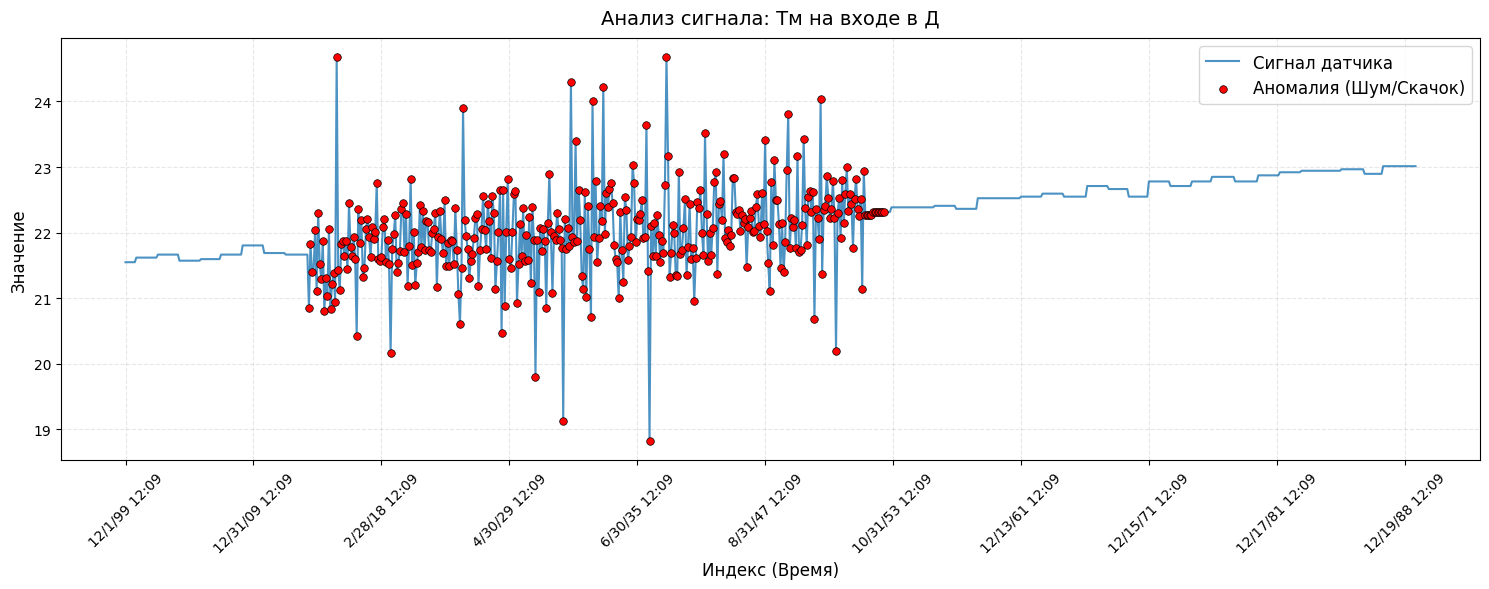

In [ ]:
def plot_anomalies_from_df(df, time_col='TimeStamp', label_col='0 - Bad, 1 - Good', 
                           start_idx=None, end_idx=None):
    """
    Строит график сигнала и выделяет красным цветом точки аномалий.
    """
    # Определяем название колонки с самим датчиком (та, которая не время и не метка)
    sensor_col = [col for col in df.columns if col not in [time_col, label_col]][0]
    
    # Делаем срез данных, если запрошен зум
    plot_df = df.iloc[start_idx:end_idx].copy()
    
    # Разделяем данные на норму и аномалии
    # Напоминание: в нашем формате 0 - это аномалия (Bad), 1 - это норма (Good)
    anomalies = plot_df[plot_df[label_col] == 0]
    
    plt.figure(figsize=(15, 6))
    
    # 1. Рисуем основной сигнал (синяя линия)
    # Используем индекс для оси X, чтобы избежать проблем с форматами времени в matplotlib
    plt.plot(plot_df.index, plot_df[sensor_col], label='Сигнал датчика', color='#1f77b4', linewidth=1.5, alpha=0.8)
    
    # 2. Накладываем точки аномалий (красные точки)
    # zorder=5 гарантирует, что точки будут нарисованы ПОВЕРХ линии
    plt.scatter(anomalies.index, anomalies[sensor_col], color='red', label='Аномалия (Шум/Скачок)', 
                s=30, zorder=5, edgecolors='black', linewidths=0.5)
    
    # Настройка внешнего вида
    plt.title(f'Анализ сигнала: {sensor_col}', fontsize=14, pad=10)
    plt.xlabel('Индекс (Время)', fontsize=12)
    plt.ylabel('Значение', fontsize=12)
    plt.legend(fontsize=12, loc='upper right')
    plt.grid(True, alpha=0.3, linestyle='--')
    
    # Опционально: настраиваем метки оси X так, чтобы они показывали реальное время (через каждые N точек)
    num_ticks = 10
    step = max(1, len(plot_df) // num_ticks)
    tick_indices = plot_df.index[::step]
    tick_labels = plot_df[time_col].iloc[::step]
    plt.xticks(tick_indices, tick_labels, rotation=45)
    
    plt.tight_layout()
    plt.show()

def plot_anomalies_from_csv(csv_path, time_col='TimeStamp', label_col='0 - Bad, 1 - Good', 
                            start_idx=None, end_idx=None):
    """
    Удобная обертка: читает файл отчета инференса и сразу рисует график.
    """
    print(f"Загрузка файла: {csv_path}...")
    # Читаем с защитой от BOM-символа
    df = pd.read_csv(csv_path, encoding='utf-8-sig')
    df.columns = df.columns.str.strip() # Очистка невидимых пробелов
    
    if label_col not in df.columns:
        print(f"ОШИБКА: Колонка разметки '{label_col}' не найдена в файле.")
        return
        
    plot_anomalies_from_df(df, time_col, label_col, start_idx, end_idx)


plot_anomalies_from_csv("inference_reports/Тм_на_входе_в_Д_report.csv")

In [68]:
compute_metrics(labels_true=labels_true, labels_pred=labels_pred)

{'accuracy': 0.9833, 'precision': 0.9651, 'recall': 0.9972, 'f1': 0.9809}